In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Dataset_Day7.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,33.6,0.627,50,1
1,1,85,66,26.6,0.351,31,0
2,8,183,64,23.3,0.672,32,1
3,1,89,66,28.1,0.167,21,0
4,0,137,40,43.1,2.288,33,1


In [4]:
cols = ["Glucose", "BloodPressure", "BMI", "DiabetesPedigreeFunction"]
df[cols] = df[cols].replace(0, np.nan)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   BMI                       757 non-null    float64
 4   DiabetesPedigreeFunction  768 non-null    float64
 5   Age                       768 non-null    int64  
 6   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 42.1 KB


In [5]:
numeric_col=[]

for col in df.columns:
    if df[col].dtype.name != 'object':
        numeric_col.append(col)

print(numeric_col)

median_value = df[numeric_col].median()
print(median_value)

df = df.fillna(median_value)
df.info()

['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
BMI                          32.3000
DiabetesPedigreeFunction      0.3725
Age                          29.0000
Outcome                       0.0000
dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   BMI                       768 non-null    float64
 4   DiabetesPedigreeFunction  768 non-null    float64
 5   Age                       768 non-null    int64  
 6   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(3)
m

In [6]:
for col in cols:
    df[col] = (df[col] - df[col].mean()) / df[col].std()

# Outlier Detection using z-score
OutlierRows = df[
    (df["Glucose"] > 3) | (df["Glucose"] < -3) |
    (df["BloodPressure"] > 3) | (df["BloodPressure"] < -3) |
    (df["BMI"] > 3) | (df["BMI"] < -3) |
    (df["DiabetesPedigreeFunction"] > 3) | (df["DiabetesPedigreeFunction"] < -3)
]

print("% of Outlier rows in the dataset is " + str(len(OutlierRows) / len(df) * 100) + "\n")

data_OutlierFree = df.drop(OutlierRows.index, axis=0)

% of Outlier rows in the dataset is 2.734375



In [7]:
# Data Splitting into 80% training and 20% testing data

X = data_OutlierFree.drop("Outcome",axis=1)
y = data_OutlierFree["Outcome"]

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=99)
len(X_train),len(X_test)

(597, 150)

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Fit a Decision Tree model as comparison
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print("F1-Score of Decision Tree is {}".format(f1_score(y_test, y_pred)))
print("Accuracy of Decision Tree is {}".format(accuracy_score(y_test, y_pred)))


# Fit a Bagging Classifier
from sklearn.ensemble import BaggingClassifier

bag_clf = BaggingClassifier(n_estimators = 100) ## n_estimators stand for number of sub trees we are looking to get
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)
print("F1-Score of Bagging classifier of Decision Tree is {}".format(f1_score(y_test, y_pred)))
print("Accuracy of Bagging classifier of Decision Tree is {}".format(accuracy_score(y_test, y_pred)))

F1-Score of Decision Tree is 0.5934065934065934
Accuracy of Decision Tree is 0.7533333333333333
F1-Score of Bagging classifier of Decision Tree is 0.7058823529411765
Accuracy of Bagging classifier of Decision Tree is 0.8333333333333334


Observations:-

F1-Score of Decision Tree is 61.70% and that of Bagging Classifier is 67.47%
Accuracy of Decision Tree is 76.00% and that of Bagging Classifier is 82.00%
Bagging clearly performs better than Decision tree in both F1-score and Accuracy.
Improved F1-score indicates a better balance between Precision and Recall.

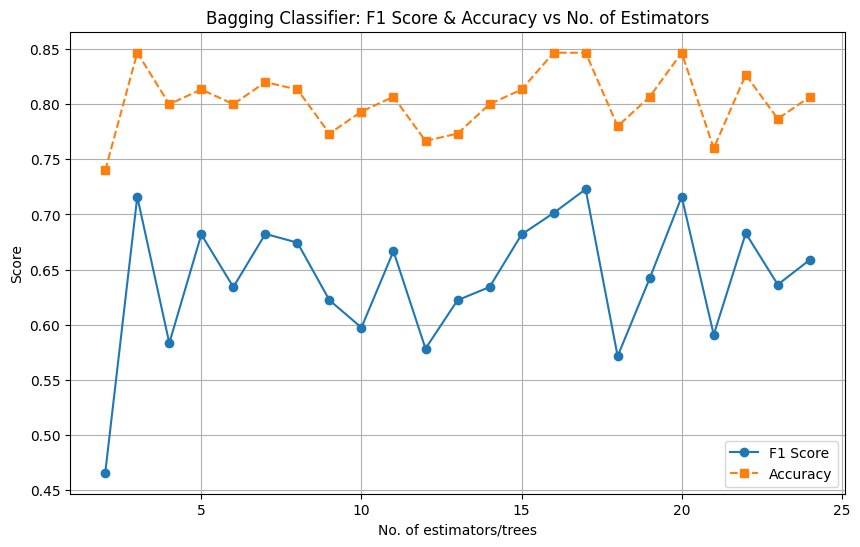

In [9]:
n_estimators = np.arange(2, 25).tolist()
scores = []         # F1 scores
accuracy = []       # Accuracy scores

for i in n_estimators:
    bag_clf = BaggingClassifier(n_estimators=i)
    bag_clf.fit(X_train, y_train)
    y_pred = bag_clf.predict(X_test)

    scores.append(f1_score(y_test, y_pred))
    accuracy.append(accuracy_score(y_test, y_pred))

# Plot both
plt.figure(figsize=(10, 6))
plt.plot(n_estimators, scores, label='F1 Score', marker='o')
plt.plot(n_estimators, accuracy, label='Accuracy', marker='s', linestyle='--')

plt.xlabel("No. of estimators/trees")
plt.ylabel("Score")
plt.title("Bagging Classifier: F1 Score & Accuracy vs No. of Estimators")
plt.legend()
plt.grid(True)
plt.show()

Both F1-score and Accuracy improve significantly for 1 - 10 estimators, but start fluctuating more past 10 estimators.
F1-score peaks at 15 and around 21 and some drops can be noted at around 13 and 23 respectively.
Accuracy also peaks at 15 and around 21 and drops noticeably at around 13 and 23 respectively.
In that sense, we can say that F1-score and Accuracy follow as similar trend.
However, Accuracy shows more stability than F1-score.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Fit the model
rf = RandomForestClassifier(n_estimators=100)  # Note: n_estimators = how many trees to grow
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("F1-Score of Random Forest Classifier of Decision Tree is {}".format(f1_score(y_test, y_pred)))
print("Accuracy of Random Forest Classifier of Decision Tree is {}".format(accuracy_score(y_test, y_pred)))

F1-Score of Random Forest Classifier of Decision Tree is 0.6588235294117647
Accuracy of Random Forest Classifier of Decision Tree is 0.8066666666666666


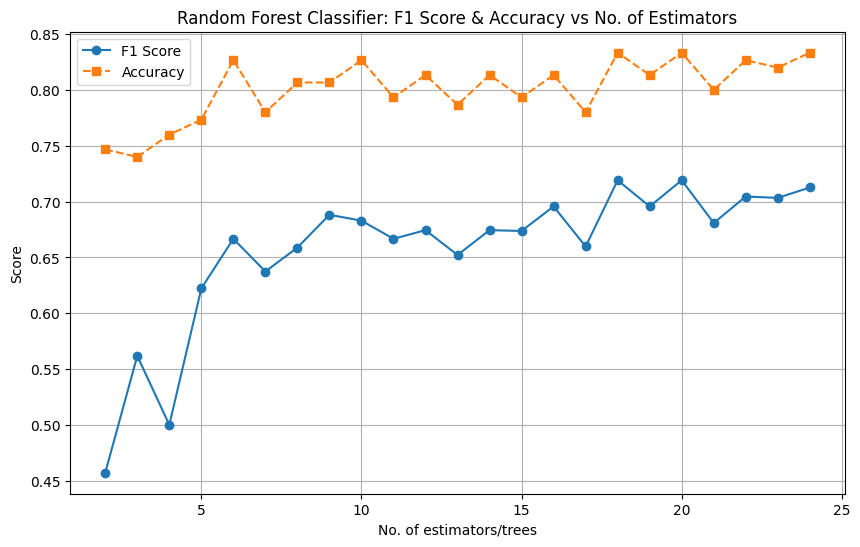

Estimator no. with highest F1 Score is: 18
Estimator no. with highest F1 Score is: 20


In [11]:
estimator_range = np.arange(2, 25).tolist()

models = []
scores = []      # F1 scores
accuracy = []    # Accuracy scores

for i in estimator_range:
    rf = RandomForestClassifier(n_estimators=i, random_state=99)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    # models.append(clf)
    scores.append(f1_score(y_test, y_pred))
    accuracy.append(accuracy_score(y_test, y_pred))

# Plot both F1 Score and Accuracy
plt.figure(figsize=(10, 6))
plt.plot(estimator_range, scores, label='F1 Score', marker='o')
plt.plot(estimator_range, accuracy, label='Accuracy', marker='s', linestyle='--')

plt.xlabel("No. of estimators/trees")
plt.ylabel("Score")
plt.title("Random Forest Classifier: F1 Score & Accuracy vs No. of Estimators")
plt.legend()
plt.grid(True)
plt.show()

# Print best F1 Score
for i in range(len(scores)):
    if scores[i] == max(scores):
        print("Estimator no. with highest F1 Score is: {}".format(estimator_range[i]))



F1-score and Accuracy generally improve with increasing number of estimators with slight fluctuations.
F1-score peaks at 18 and 20 respectively and some significant drops can be noticed at 4, 17 and 21 respectively.
Accuracy peaks at 6, 18 and 20 respectively and some significant drops can be noticed at 7 and 17 respectively.
F1-score and Accuracy are generally stable, with Accuracy showing slightly more stability. However, F1-score varies significantly between 2 to 5.

In [12]:
from sklearn.ensemble import AdaBoostClassifier

#fit the model
rf = AdaBoostClassifier(n_estimators=100) ## find other parameter values for max_features

### Note: Parameter - n_estimators stands for how many tree we want to grow

rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)

print("F1-Score of Boosting Classifier of Decision Tree is {}".format(f1_score(y_test, y_pred)))
print("Accuaracy of Boosting Classifier of Decision Tree is {}".format(accuracy_score(y_test, y_pred)))

F1-Score of Boosting Classifier of Decision Tree is 0.6666666666666666
Accuaracy of Boosting Classifier of Decision Tree is 0.82


Estimator no. with highest F1 Score is: 3


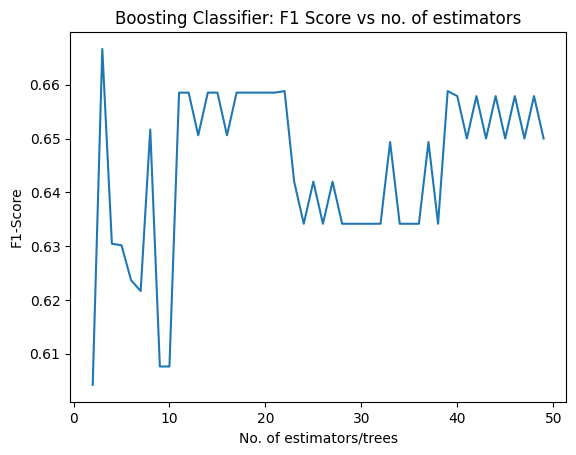

In [13]:
estimator_range=np.arange(2,50) # you can take a generated sequence using np.arange too

models=[]
scores=[]
for i in estimator_range:
    
    rf = AdaBoostClassifier(n_estimators=i, random_state=99)
    rf.fit(X_train,y_train)
    y_pred = rf.predict(X_test)
    
#     models.append(clf)
    scores.append(f1_score(y_test, y_pred))
    
plt.plot(estimator_range,scores)
plt.xlabel("No. of estimators/trees")
plt.ylabel("F1-Score")
plt.title("Boosting Classifier: F1 Score vs no. of estimators")

for i in range(len(scores)):
    if(scores[i] == max(scores)):
        print("Estimator no. with highest F1 Score is: {}".format(estimator_range[i]))

Sharp rise in F1-score can be noted at no. of estimators = 3.
After estimator 10, F1-score fluctuates slightly between 0.65 and 0.66.
Between 12 to 20 (approx) there is some stablity.
No improvemnet is seen beyond 10 estimators.